# EXERCISE 3 Numerical Limits and Precision Loss

## 1. Analytical Proof of the Limit
According to the task , we consider the function:
$$f(x) = \begin{cases} 1 & \text{for } x=0 \\ \frac{e^x - 1}{x} & \text{for } x \neq 0 \end{cases}$$

We need to prove that $\lim_{x \to 0} f(x) = 1$. ]Since substituting $x=0$ directly yields an indeterminate form of $\frac{0}{0}$ , we can apply L'Hopital's rule by differentiating the numerator and the denominator :
$$\lim_{x \to 0} \frac{e^x - 1}{x} = \lim_{x \to 0} \frac{\frac{d}{dx}(e^x - 1)}{\frac{d}{dx}(x)} = \lim_{x \to 0} \frac{e^x}{1} = \frac{e^0}{1} = 1$$ 
This analytical proof confirms that the limit approaches 1, matching the defined value at $x=0$ .

## 2. Standard Formula Evaluation
We will plot $f(x)$ using the standard formula for values of $x = 10^{-k}$, where $k = 0, \dots, 16$. 
As $k$ increases, $x$ approaches 0, allowing us to observe how floating-point arithmetic handles the operation $e^x - 1$ for extremely small numbers .

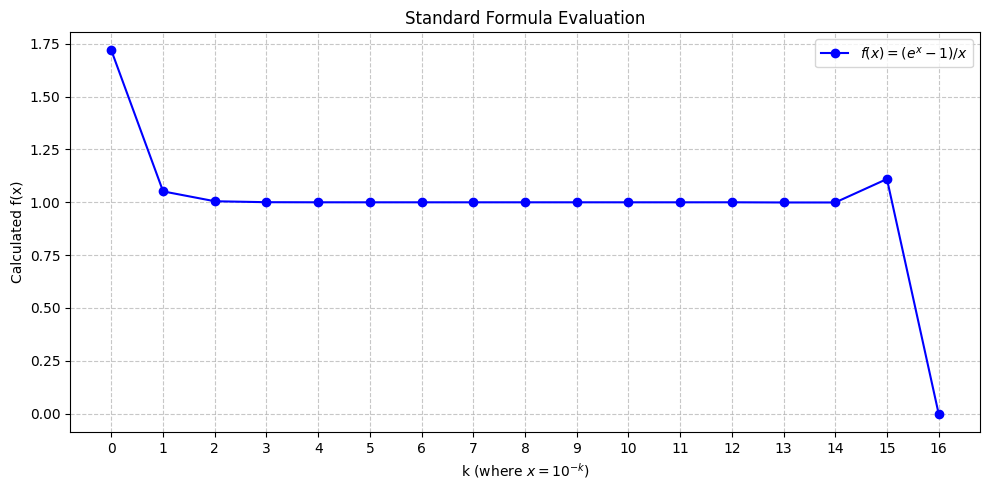

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Generate k values and corresponding x values
k_vals = np.arange(0, 17)
x_vals = 10.0**(-k_vals)

# Standard formula evaluation
f1 = (np.exp(x_vals) - 1) / x 


# Y-axis, X-axis and legend
plt.figure(figsize=(10, 5))
plt.plot(k_vals, f1, marker='o', color='blue', label='$f(x) = (e^x - 1)/x$')

plt.title('Standard Formula Evaluation')
plt.xlabel('k (where $x = 10^{-k}$)')
plt.ylabel('Calculated f(x)')
plt.xticks(k_vals)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Visualization
plt.legend()
plt.show()

## 3. Equivalent Formula Substitution
To see if simple algebraic transformations help, we use a mathematically equivalent formula based on the substitution $y = e^x$. 
The function becomes:
$$f(x) = \begin{cases} 1 & \text{for } y=1 \\ \frac{y - 1}{\log(y)} & \text{for } y \neq 1 \end{cases}$$ 

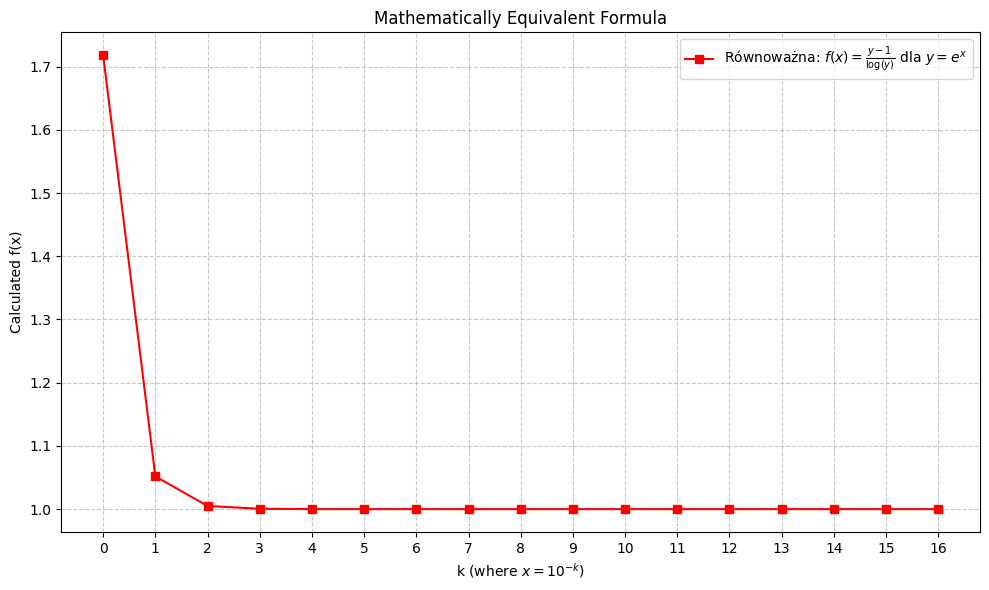

In [39]:
# Equivalent formula evaluation
# Using np.where to handle the condition where y equals exactly 1.0 in machine precision
warnings.filterwarnings("ignore", category=RuntimeWarning)

y = np.exp(x)
f2 = np.where(y == 1.0, 1.0, (y - 1) / np.log(y))

plt.figure(figsize=(10, 6))
plt.plot(k_vals, y_equivalent, marker='s', color='red', label=r'Równoważna: $f(x) = \frac{y - 1}{\log(y)}$ dla $y=e^x$')

# Y-axis, X-axis and legend
plt.title('Mathematically Equivalent Formula')
plt.xlabel('k (where $x = 10^{-k}$)')
plt.ylabel('Calculated f(x)')
plt.xticks(k_vals)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Visualization
plt.tight_layout()
plt.show()

## 4. Taylor Series Expansion
A robust way to calculate $f(x)$ with better numerical properties for small $x$ is using the Taylor series (Maclaurin series) expansion.
The expansion for $e^x$ is $1 + x + \frac{x^2}{2!} + \dots$.
Substituting this into our function and simplifying:
$$f(x) = \frac{(1 + x + \frac{x^2}{2} + \dots) - 1}{x} = 1 + \frac{x}{2} + \frac{x^2}{6} + \dots$$ 
For values of $x$ close to zero, we can truncate this to the first-order approximation: $f(x) \approx 1 + \frac{x}{2}$.This completely eliminates the problematic subtraction.

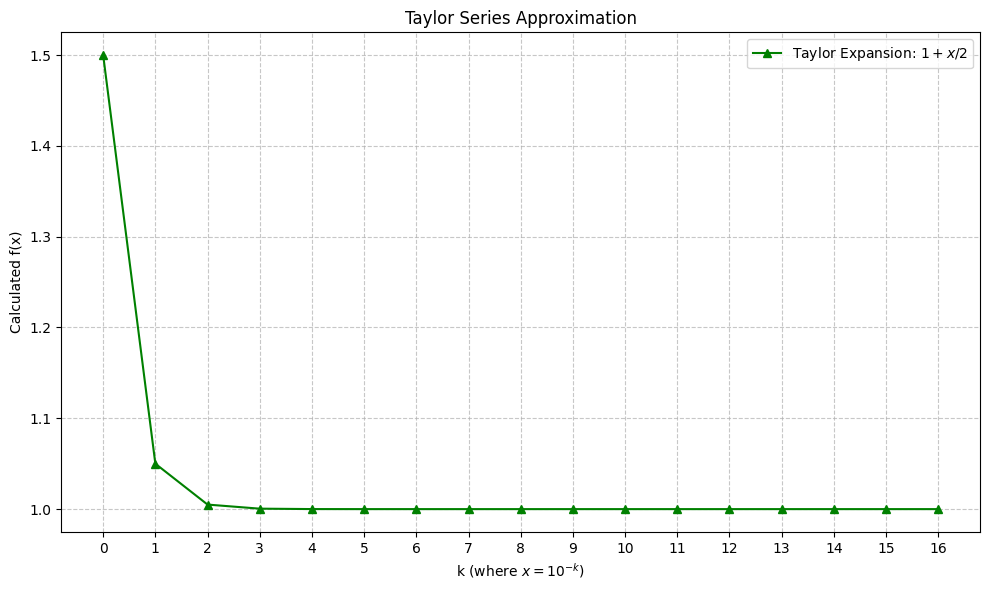

In [28]:
# Taylor series approximation (first order)
f3 = 1 + x_vals / 2

# Generating the plot
plt.figure(figsize=(10, 6))

# Drawing a curve (Taylor series)
plt.plot(k_vals, f3, marker='^', color='green', label=r'Taylor Expansion: $1 + x/2 $')

# Y-axis, X-axis and legend
plt.title('Taylor Series Approximation')
plt.xlabel('k (where $x = 10^{-k}$)')
plt.ylabel('Calculated f(x)')
plt.xticks(k_vals)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Visualization
plt.tight_layout()
plt.show()

## 5. Built-in `expm1` Function and Conclusions
Finally, we use the `numpy.expm1(x)` function. This library function is specifically optimized to calculate $e^x - 1$ with high precision for values of $x$ very close to zero.

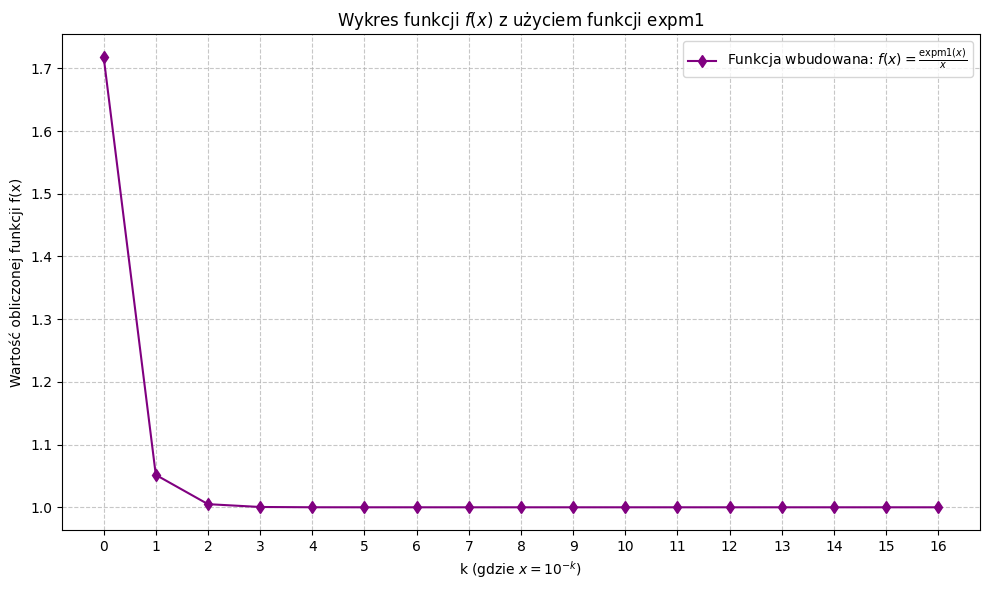

In [25]:
# Calculating values using optimized function exmp1
f4 = np.expm1(x) / x

# Generating the plot
plt.figure(figsize=(10, 6))

# Drawing a curve (expm1)
plt.plot(k, f4, marker='d', color='purple', label=r'Funkcja wbudowana: $f(x) = \frac{\mathrm{expm1}(x)}{x}$')

# Y-axis, X-axis and legend
plt.title('Wykres funkcji $f(x)$ z użyciem funkcji expm1')
plt.xlabel('k (gdzie $x = 10^{-k}$)')
plt.ylabel('Wartość obliczonej funkcji f(x)')
plt.xticks(k_vals) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Visualization
plt.tight_layout()
plt.show()

### A summary and comparison of all methods in a single chart  

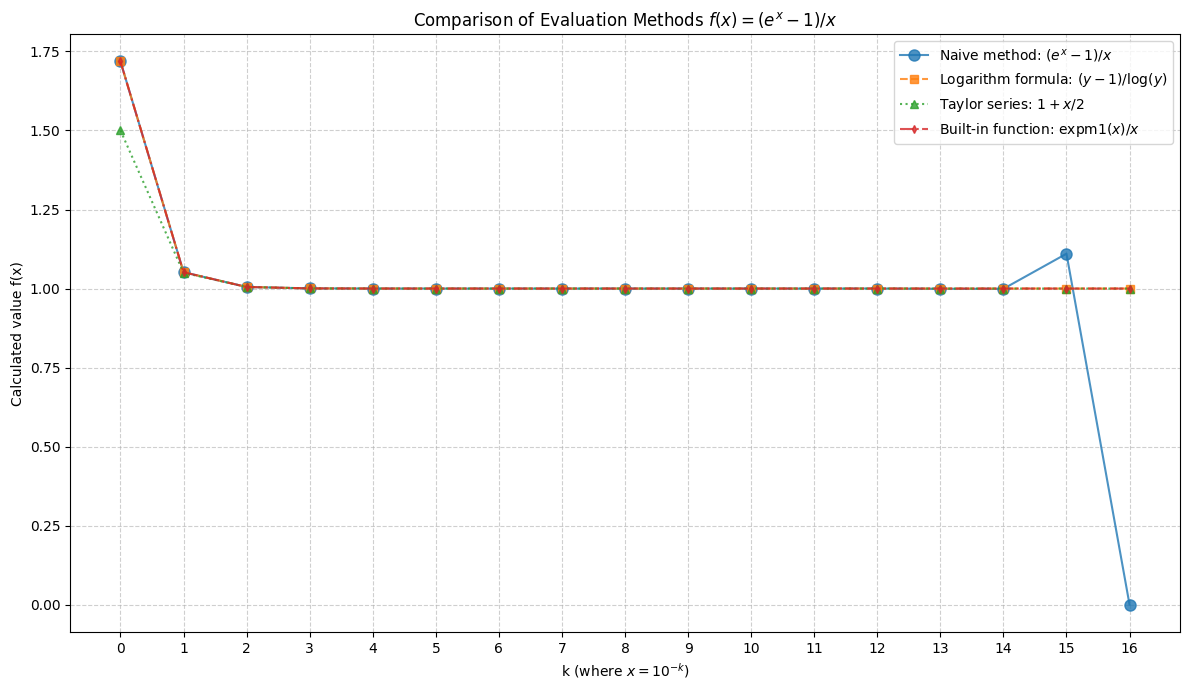

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

k = np.arange(0, 17)
x = 10.0**(-k)

# Combined Plot for Final Comparison
plt.figure(figsize=(12, 7))

# Drawing all curves
plt.plot(k, f1, 'o-', label=r'Naive method: $(e^x - 1)/x$', markersize=8, alpha=0.8)
plt.plot(k, f2, 's--', label=r'Logarithm formula: $(y-1)/\log(y)$', markersize=6, alpha=0.8)
plt.plot(k, f3, '^:', label=r'Taylor series: $1 + x/2$', markersize=6, alpha=0.8)
plt.plot(k, f4, 'd-.', label=r'Built-in function: $\mathrm{expm1}(x)/x$', markersize=4, alpha=0.8)

# Y-axis, X-axis and legend
plt.title('Comparison of Evaluation Methods $f(x) = (e^x - 1)/x$')
plt.xlabel('k (where $x = 10^{-k}$)')
plt.ylabel('Calculated value f(x)')
plt.xticks(k)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Visualization
plt.tight_layout()
plt.show()